# MOL518 Homework 3
David Godovich  
2/20/2026

# Problem 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
data = np.loadtxt('HW3_data/Births.csv', delimiter=',', skiprows=1)
# columns = ['time', 'sex', 'weight', 'time_midnight']

In [3]:
#a
sex, weight, time_after_midnight = [data[:,1], data[:,2], data[:,3]]

In [4]:
#b
female, male = [list(sex).count(1), list(sex).count(2)]
print(f'There are {female} female babies and {male} male babies')

There are 18 female babies and 26 male babies


#### b
The number of babies is a binomial distribution. This is assuming that the sex of each baby is independent and the probability of a male or female baby is the same for all births.

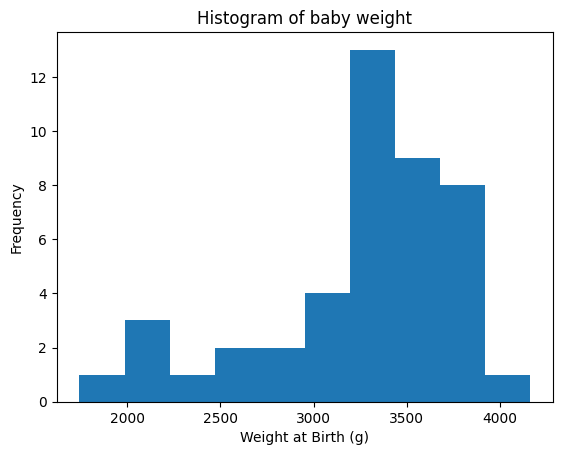

In [5]:
#c
plt.hist(weight, bins = 10)
plt.title('Histogram of baby weight')
plt.xlabel('Weight at Birth (g)')
plt.ylabel('Frequency')
plt.show()

#### c
Birth weight appears to follow a normal distribution with a longer tail on the left. This is probably because of pre-term births. This assumes that samples are independent.

In [6]:
#d
hour_dict = {}
for i in range(0,24):
    min_time = i*60
    max_time = (i+1)*60
    count = sum((time_after_midnight > min_time) & (time_after_midnight < max_time))
    hour_dict[i] = count

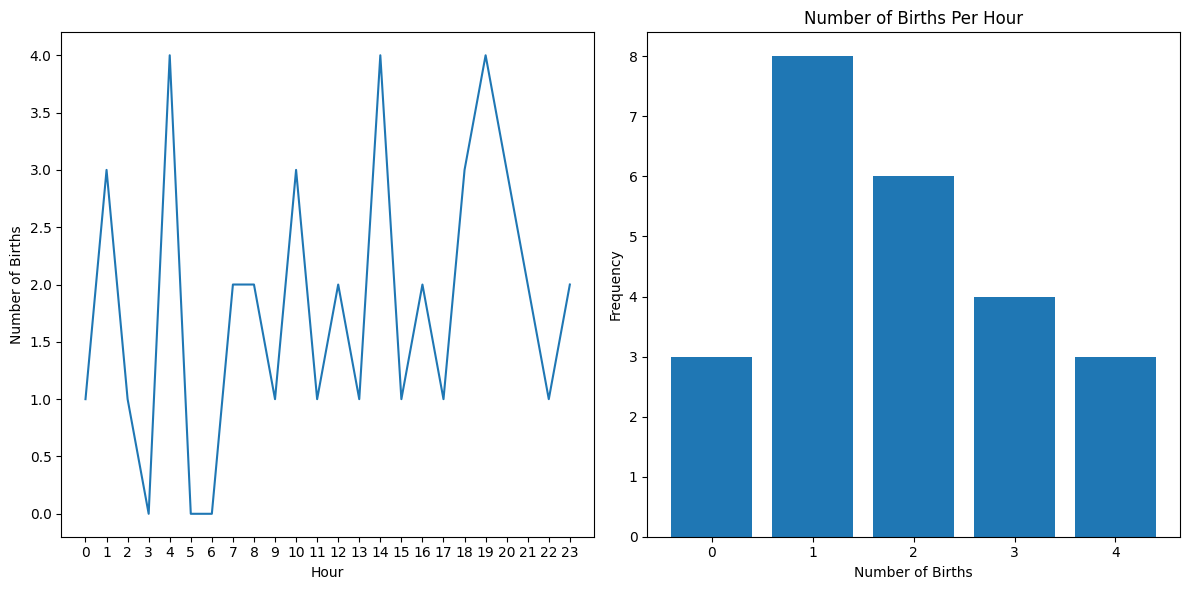

In [7]:
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(hour_dict.values())
ax[0].set_xticks(range(0,24))
ax[0].set_ylabel('Number of Births')
ax[0].set_xlabel('Hour')

ax[1].bar(*np.unique(list(hour_dict.values()), return_counts = True))
ax[1].set_title('Number of Births Per Hour')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Number of Births')

plt.tight_layout()
plt.show()

#### d
This appears to be a Poisson distribution. The Poisson distribution is useful for counting the number of occurances in a time interval. It assumes that samples are indenpendent and the mean is constant. Birth time might have a bias against late night hours, but this is not visible in this dataset.

In [8]:
#e
wait_times = [time_after_midnight[i+1] - time_after_midnight[i] for i in range(len(time_after_midnight)-1)]

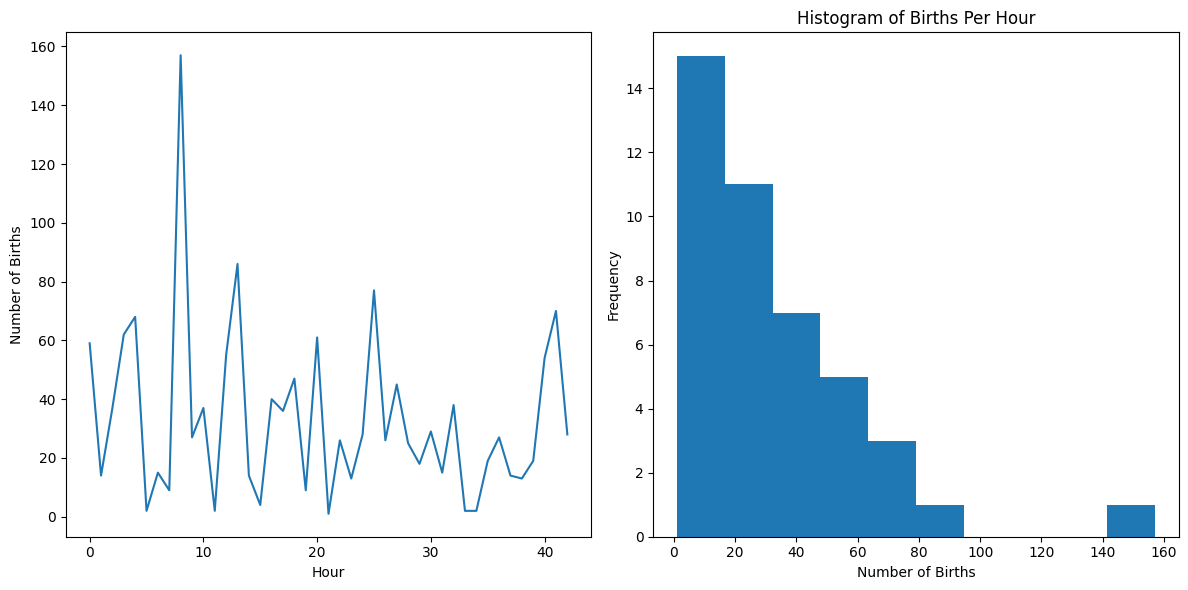

In [9]:
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(wait_times)
# ax[0].set_xticks(range(0,24))
ax[0].set_ylabel('Number of Births')
ax[0].set_xlabel('Hour')

ax[1].hist(wait_times, bins = 10)
ax[1].set_title('Histogram of Births Per Hour')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Number of Births')

plt.tight_layout()
plt.show()

#### e
This appears to follow an exponential distribution. Exponential distributions are often relevant for time between events that follow a Poisson distribution (as was seen in d). It has similar assumptions to the Poisson distribution. 

# Problem 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

In [11]:
#a, b
data = pd.read_csv('HW3_data/Chicken-Weights.csv', usecols=[0,1])
group_means = data.groupby(['Feed']).mean().values.flatten()
group_var = data.groupby(['Feed']).var().values.flatten()

print('means: \n', group_means, '\n\nvars: \n', group_var)
#note that pandas groupby calculates the sample standard deviation and variance

means: 
 [323.58333333 160.2        218.75       276.90909091 246.42857143
 328.91666667] 

vars: 
 [4151.71969697 1491.95555556 2728.56818182 4212.09090909 2929.95604396
 2384.99242424]


In [12]:
#c
def cv_calc(array):
    mean = np.mean(array)
    std = np.std(array, ddof = 1)
    cv = std/mean
    return cv

In [13]:
#d
data.groupby(['Feed']).apply(cv_calc)

Feed
casein       0.199126
horsebean    0.241110
linseed      0.238792
meatmeal     0.234375
soybean      0.219654
sunflower    0.148476
dtype: float64

#### e
Coefficient of variation is a measure of the spread from the mean of a dataset. In this example, the sunflower feed chickens have the lowest coefficient of variation, and horsebean feed chickens have the greatest.

#### f
In this experiment, the chicken weights are compared only at the endpoint. I would instead measure the weight gain relative to the start of the feed to eliminate the possiblity of one group of chickens simply starting with a greater weight. I would also increase the number of chickens in each group to have greater confidence in the result.

## problem 2 without pandas

In [14]:
data_2 = np.loadtxt('HW3_data/Chicken-Weights.csv', delimiter = ',', dtype = np.ndarray, usecols=[0,1], skiprows = 1)

In [15]:
feeds = np.unique(data_2[:,0])

In [16]:
means = {}
variances = {}
covariances = {}
for feed in feeds:
    subset = data_2[data_2[:,0] == feed]
    weights = subset[:,1].astype(int)
    mean, var = [np.mean(weights), np.var(weights, ddof = 1)]
    means[feed] = mean
    variances[feed] = var
    covariances[feed] = cv_calc(weights)

In [17]:
means
# print(means.values()) #if you actually want a list, I think the dictionary output is much more readable

{'casein': np.float64(323.5833333333333),
 'horsebean': np.float64(160.2),
 'linseed': np.float64(218.75),
 'meatmeal': np.float64(276.90909090909093),
 'soybean': np.float64(246.42857142857142),
 'sunflower': np.float64(328.9166666666667)}

In [18]:
variances

{'casein': np.float64(4151.719696969698),
 'horsebean': np.float64(1491.9555555555555),
 'linseed': np.float64(2728.568181818182),
 'meatmeal': np.float64(4212.09090909091),
 'soybean': np.float64(2929.956043956044),
 'sunflower': np.float64(2384.9924242424245)}

In [19]:
covariances

{'casein': np.float64(0.19912595319569135),
 'horsebean': np.float64(0.24111011557956186),
 'linseed': np.float64(0.23879176387284906),
 'meatmeal': np.float64(0.23437519916930136),
 'soybean': np.float64(0.21965419053763183),
 'sunflower': np.float64(0.14847646584967653)}

# Problem 3

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [21]:
data = np.loadtxt('HW3_data/Births.csv', delimiter=',', skiprows=1)
# columns = ['time', 'sex', 'weight', 'time_midnight']

In [22]:
sex, weight, time_after_midnight = [data[:,1], data[:,2], data[:,3]]

hour_dict = {}
for i in range(0,24):
    min_time = i*60
    max_time = (i+1)*60
    count = sum((time_after_midnight > min_time) & (time_after_midnight < max_time))
    hour_dict[i] = count

#only need a list for this, don't need to keep track of which hour has what value
hourly_births = list(hour_dict.values())

wait_times = [time_after_midnight[i+1] - time_after_midnight[i] for i in range(len(time_after_midnight)-1)]

In [23]:
weight_mean, weight_std = [np.mean(weight), np.std(weight)]
hour_mean, hour_std = [np.mean(hourly_births), np.std(hourly_births)]
time_diff_mean, time_diff_std = [np.mean(wait_times), np.std(wait_times)]

In [24]:
normal_distro = np.random.normal(weight_mean,weight_std, 1000)
poisson_distro = np.random.poisson(hour_mean, 1000)
exponential_distro = np.random.exponential(time_diff_mean, 1000)

Text(0, 0.5, 'Actual Data Frequency')

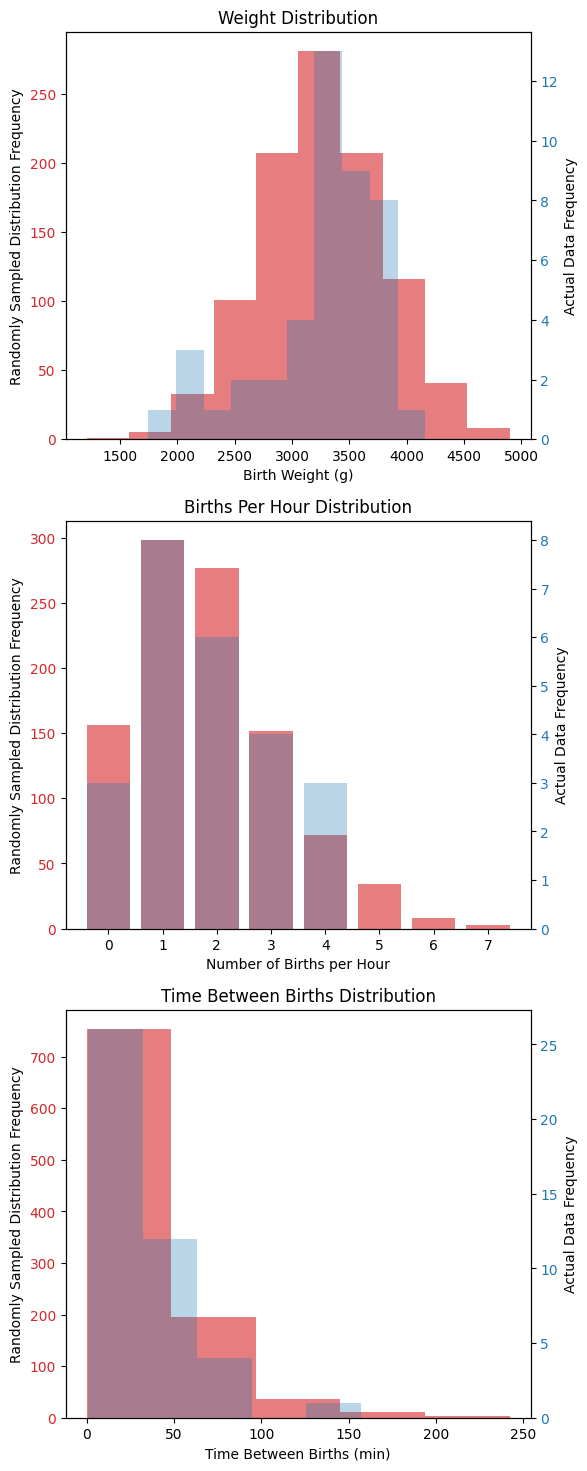

In [25]:
fig, ax = plt.subplots(3, 1, figsize = (6, 18))
ax[0].hist(normal_distro, alpha = 0.6, color = 'tab:red')
ax[0].set_title('Weight Distribution')
ax[0].set_xlabel('Birth Weight (g)')
ax[0].set_ylabel('Randomly Sampled Distribution Frequency')
ax[0].tick_params(axis = 'y', labelcolor = 'tab:red')
ax2 = ax[0].twinx()
ax2.hist(weight, alpha = 0.3, color = 'tab:blue')
ax2.tick_params(axis = 'y', labelcolor = 'tab:blue')
ax2.set_ylabel('Actual Data Frequency')

ax[1].bar(*np.unique(poisson_distro, return_counts = True), alpha = 0.6, color = 'tab:red')
ax[1].set_title('Births Per Hour Distribution')
ax[1].set_xlabel('Number of Births per Hour')
ax[1].set_ylabel('Randomly Sampled Distribution Frequency')
ax[1].tick_params(axis = 'y', labelcolor = 'tab:red')
ax2 = ax[1].twinx()
ax2.bar(*np.unique(hourly_births, return_counts = True), alpha = 0.3, color = 'tab:blue')
ax2.tick_params(axis = 'y', labelcolor = 'tab:blue')
ax2.set_ylabel('Actual Data Frequency')

ax[2].hist(exponential_distro, alpha = 0.6, color = 'tab:red', bins = 5)
ax[2].set_title('Time Between Births Distribution')
ax[2].set_xlabel('Time Between Births (min)')
ax[2].set_ylabel('Randomly Sampled Distribution Frequency')
ax[2].tick_params(axis = 'y', labelcolor = 'tab:red')
ax2 = ax[2].twinx()
ax2.hist(wait_times, alpha = 0.3, color = 'tab:blue', bins = 5)
ax2.tick_params(axis = 'y', labelcolor = 'tab:blue')
ax2.set_ylabel('Actual Data Frequency')

In [26]:
#b
def bootstrap_values(array):
    bootstrap_mean = np.mean(stats.bootstrap([array], np.mean).bootstrap_distribution)
    bootstrap_var = np.mean(stats.bootstrap([array], np.var).bootstrap_distribution)
    bootstrap_std = np.mean(stats.bootstrap([array], np.std).bootstrap_distribution)

    return [bootstrap_mean, bootstrap_var, bootstrap_std]

In [27]:
print('Bootstrapped mean of hourly births: ', bootstrap_values(hourly_births)[0])
print('Bootstrapped var of hourly births: ',bootstrap_values(hourly_births)[1])
print('Bootstrapped std of hourly births: ',bootstrap_values(hourly_births)[2])

Bootstrapped mean of hourly births:  1.83507934126746
Bootstrapped var of hourly births:  1.410610505494994
Bootstrapped std of hourly births:  1.1816012261931066


In [28]:
print('Bootstrapped mean of wait times: ', bootstrap_values(wait_times)[0])
print('Bootstrapped var of wait times: ',bootstrap_values(wait_times)[1])
print('Bootstrapped std of wait times: ',bootstrap_values(wait_times)[2])

Bootstrapped mean of wait times:  33.2269854892466
Bootstrapped var of wait times:  830.0603359416526
Bootstrapped std of wait times:  28.21551454526388


In [29]:
#c
print('Randomly generated mean of hourly births: ', np.mean(poisson_distro))
print('Randomly generated var of hourly births: ', np.var(poisson_distro))
print('Randomly generated std of hourly births: ', np.std(poisson_distro))

print('Randomly generated mean of wait times: ', np.mean(exponential_distro))
print('Randomly generated var of wait times: ', np.var(exponential_distro))
print('Randomly generated std of wait times: ', np.std(exponential_distro))

Randomly generated mean of hourly births:  1.835
Randomly generated var of hourly births:  1.843775
Randomly generated std of hourly births:  1.3578567671150001
Randomly generated mean of wait times:  34.175067254756506
Randomly generated var of wait times:  1136.3359148637276
Randomly generated std of wait times:  33.70958194436305


#### c
The means of the bootstrapped and actual distributions are quite close to the estimated means from the randomly created distributions, but the variance and standard deviations are further apart. This is not surprising - the randomly simulated distributions are based on the means, so they will have the same mean as resampled data. Simulated distributions fail to capture real life variation in the datasets like premature births or multiple pregnancy (twins) that is captured by the bootstrapping technique.

#### d
I used 9999 samples for bootstrapping. This is the default value from the scipy package. The number of samples for bootstrapping should be relatively high to acurrately capture the true distribution, but not so high to be computationally intensive. 9999 is high enough to get a highly accurate estimation of the true data.